график для мощности критерия

In [1]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt


Левый квантиль (t1): 0.7674
Правый квантиль (t2): 1.2717


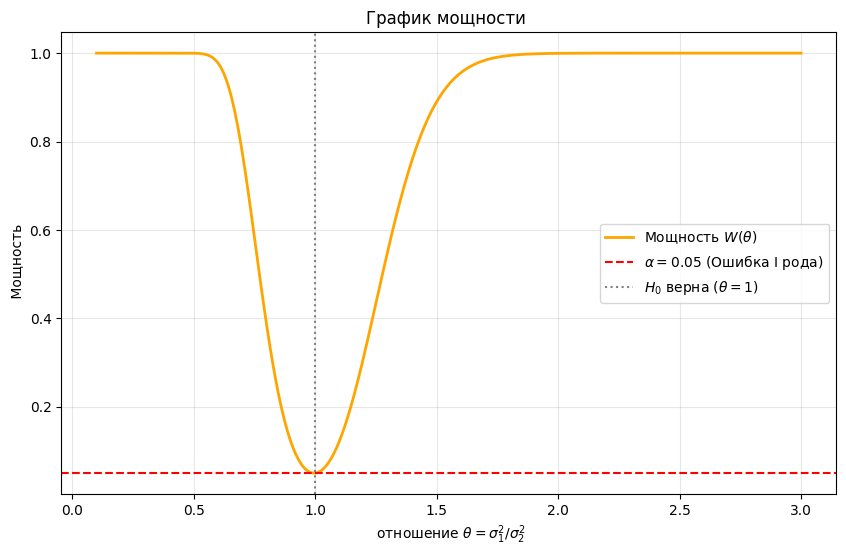

In [2]:

n = 139  # Египтяне
m = 1000 # Европейцы
alpha = 0.05


t1 = st.f.ppf(alpha / 2, dfn=n-1, dfd=m-1)
t2 = st.f.ppf(1 - alpha / 2, dfn=n-1, dfd=m-1)

print(f"Левый квантиль (t1): {t1:.4f}")
print(f"Правый квантиль (t2): {t2:.4f}")


def power_function(theta):
    
    

    prob_left = st.f.cdf(t1, dfn=n-1, dfd=m-1, scale=theta)
    
    
    prob_right = 1 - st.f.cdf(t2, dfn=n-1, dfd=m-1, scale=theta)
    
    
    return prob_left + prob_right


theta_val = np.linspace(0.1, 3.0, 500)

# Считаем мощность для каждого theta
W_ = [power_function(th) for th in theta_val]


plt.figure(figsize=(10, 6))
plt.plot(theta_val, W_, color='orange', lw=2, label='Мощность $W(\\theta)$')


plt.axhline(alpha, color='red', linestyle='--', label=f'$\\alpha = {alpha}$ (Ошибка I рода)')
plt.axvline(1.0, color='gray', linestyle=':', label='$H_0$ верна ($\\theta=1$)')

plt.title('График мощности ')
plt.xlabel(' отношение $\\theta = \\sigma_1^2 / \\sigma_2^2$')
plt.ylabel(' Мощность')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()